# Tom and Jerry EfficientNet Multi-label Classifier

이 노트북은 YOLO 같은 객체 검출이 아니라, 한 프레임에 **Tom / Jerry가 각각 있는지**를 예측하는 EfficientNet-B0 기반 멀티라벨 분류 모델입니다.

라벨 구조:

- `tom_jerry_0` -> `[tom=0, jerry=0]`
- `tom` -> `[tom=1, jerry=0]`
- `jerry` -> `[tom=0, jerry=1]`
- `tom_jerry_1` -> `[tom=1, jerry=1]`

In [22]:
# 기본 유틸리티와 딥러닝 라이브러리를 불러옵니다.
import csv
import math
import os
import random
from collections import Counter
from pathlib import Path

# matplotlib 캐시 경고를 줄이기 위해 현재 폴더 아래 캐시를 사용합니다.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# EfficientNet-B0와 이미지 전처리 도구입니다.
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from tqdm.auto import tqdm
import matplotlib.pyplot as plt



In [ ]:
# 재현성 고정: 같은 조건에서 최대한 비슷한 결과가 나오게 합니다.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 데이터와 CSV 경로입니다. 노트북을 archive 폴더에서 실행한다고 가정합니다.
ROOT = Path.cwd()
DATA_DIR = ROOT / "tom_and_jerry" / "tom_and_jerry"
LABEL_CSV = ROOT / "ground_truth.csv"
CHALLENGE_CSV = ROOT / "challenges.csv"

# 학습 설정값입니다. 처음에는 EPOCHS를 작게 두고 잘 도는지 확인해도 좋습니다.
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 8
LR = 3e-4
VAL_START_RATIO = 0.8  # 프레임 번호 기준 뒤쪽 20%를 검증으로 사용
NUM_WORKERS = 0        # macOS/Jupyter에서는 0이 가장 안정적입니다.
USE_PRETRAINED = True  # ImageNet 사전학습 가중치를 사용합니다.

# 가능한 경우 GPU/MPS를 쓰고, 아니면 CPU로 실행합니다.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DEVICE

device(type='mps')

In [24]:
def frame_number(filename):
    """frame123.jpg 같은 파일명에서 숫자 123만 뽑습니다."""
    return int(filename.replace("frame", "").replace(".jpg", ""))

# CSV 라벨 조합과 실제 폴더 이름을 연결합니다.
label_to_folder = {
    (0, 0): "tom_jerry_0",
    (1, 0): "tom",
    (0, 1): "jerry",
    (1, 1): "tom_jerry_1",
}

# ground_truth.csv를 읽어서 이미지 경로, 라벨, 프레임 번호를 하나로 묶습니다.
rows = []
with open(LABEL_CSV, newline="") as f:
    for row in csv.DictReader(f):
        tom = int(row["tom"])
        jerry = int(row["jerry"])
        folder = label_to_folder[(tom, jerry)]
        path = DATA_DIR / folder / row["filename"]
        rows.append({
            "filename": row["filename"],
            "tom": tom,
            "jerry": jerry,
            "frame_num": frame_number(row["filename"]),
            "folder": folder,
            "path": path,
        })

# 파일 누락과 라벨 분포를 간단히 확인합니다.
missing = [r for r in rows if not r["path"].exists()]
label_counts = Counter((r["tom"], r["jerry"]) for r in rows)

print("전체 샘플 수:", len(rows))
print("누락 파일 수:", len(missing))
print("라벨 분포:")
for label, count in sorted(label_counts.items()):
    print(f"  tom={label[0]}, jerry={label[1]}: {count}")

rows[:3]

전체 샘플 수: 5478
누락 파일 수: 0
라벨 분포:
  tom=0, jerry=0: 1528
  tom=0, jerry=1: 1240
  tom=1, jerry=0: 1930
  tom=1, jerry=1: 780


[{'filename': 'frame0.jpg',
  'tom': 0,
  'jerry': 0,
  'frame_num': 0,
  'folder': 'tom_jerry_0',
  'path': PosixPath('/Users/chxe_01/Downloads/archive/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame0.jpg')},
 {'filename': 'frame1.jpg',
  'tom': 0,
  'jerry': 0,
  'frame_num': 1,
  'folder': 'tom_jerry_0',
  'path': PosixPath('/Users/chxe_01/Downloads/archive/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame1.jpg')},
 {'filename': 'frame2.jpg',
  'tom': 0,
  'jerry': 0,
  'frame_num': 2,
  'folder': 'tom_jerry_0',
  'path': PosixPath('/Users/chxe_01/Downloads/archive/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame2.jpg')}]

In [25]:
# 영상 프레임 데이터라 랜덤 분할을 하면 거의 같은 장면이 train/val에 섞일 수 있습니다.
# 그래서 프레임 번호 기준 temporal split을 사용합니다.
max_frame = max(r["frame_num"] for r in rows)
val_start = int(max_frame * VAL_START_RATIO)

train_rows = [r for r in rows if r["frame_num"] < val_start]
val_rows = [r for r in rows if r["frame_num"] >= val_start]

print("train:", len(train_rows), "val:", len(val_rows), "val_start_frame:", val_start)
print("\ntrain label distribution")
for label, count in sorted(Counter((r["tom"], r["jerry"]) for r in train_rows).items()):
    print(f"  tom={label[0]}, jerry={label[1]}: {count}")
print("\nval label distribution")
for label, count in sorted(Counter((r["tom"], r["jerry"]) for r in val_rows).items()):
    print(f"  tom={label[0]}, jerry={label[1]}: {count}")

train: 4381 val: 1097 val_start_frame: 4381

train label distribution
  tom=0, jerry=0: 1253
  tom=0, jerry=1: 956
  tom=1, jerry=0: 1520
  tom=1, jerry=1: 652

val label distribution
  tom=0, jerry=0: 275
  tom=0, jerry=1: 284
  tom=1, jerry=0: 410
  tom=1, jerry=1: 128


In [26]:
class TomJerryDataset(Dataset):
    """이미지 한 장과 [tom, jerry] 라벨을 반환하는 Dataset입니다."""
    def __init__(self, items, transform=None):
        self.items = list(items)
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        row = self.items[idx]
        image = Image.open(row["path"]).convert("RGB")
        label = torch.tensor([row["tom"], row["jerry"]], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

# 학습용 전처리: 리사이즈 + 약한 augmentation + 정규화
train_tfms = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.12, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 검증/추론용 전처리: 랜덤 변형 없이 동일하게 변환합니다.
val_tfms = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = TomJerryDataset(train_rows, train_tfms)
val_ds = TomJerryDataset(val_rows, val_tfms)

# DataLoader는 배치 단위로 이미지를 모델에 공급합니다.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

len(train_ds), len(val_ds)

(4381, 1097)

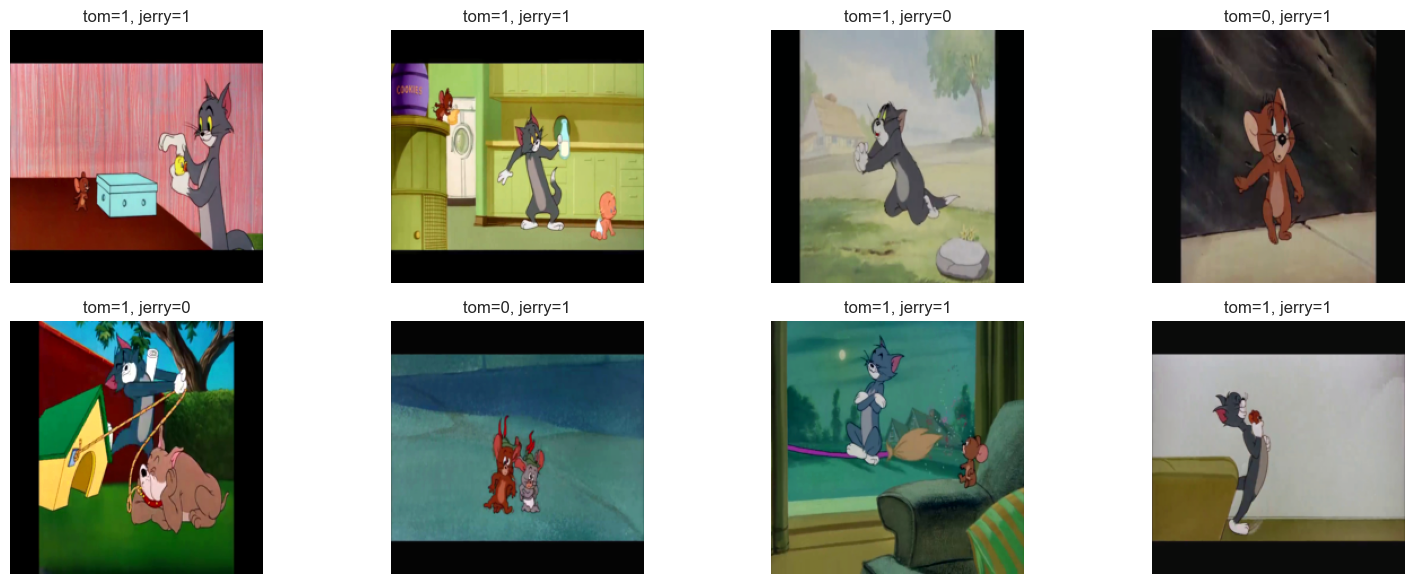

In [27]:
def show_batch(dataset, n=8):
    inv_norm = T.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
    )
    idxs = random.sample(range(len(dataset)), k=min(n, len(dataset)))
    cols = 4
    plot_rows = math.ceil(len(idxs) / cols)
    plt.figure(figsize=(cols * 4, plot_rows * 3))
    for i, idx in enumerate(idxs, 1):
        image, label = dataset[idx]
        image = inv_norm(image).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.subplot(plot_rows, cols, i)
        plt.imshow(image)
        plt.title(f"tom={int(label[0])}, jerry={int(label[1])}")
        plt.axis("off")
    plt.tight_layout()

show_batch(train_ds, n=8)

In [28]:
def build_model(use_pretrained=True):
    """EfficientNet-B0의 마지막 분류층만 Tom/Jerry 2개 출력으로 바꿉니다."""
    try:
        weights = EfficientNet_B0_Weights.DEFAULT if use_pretrained else None
        model = efficientnet_b0(weights=weights)
    except Exception as e:
        # 사전학습 가중치 다운로드가 막힌 경우에도 랜덤 초기화로 실행되게 합니다.
        print("pretrained weight 로드 실패, 랜덤 초기화로 진행합니다:", repr(e))
        model = efficientnet_b0(weights=None)

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 2)  # [tom_logit, jerry_logit]
    return model

model = build_model(USE_PRETRAINED).to(DEVICE)

# 양성/음성 비율을 반영해 클래스 불균형을 조금 보정합니다.
tom_pos = sum(r["tom"] for r in train_rows)
jerry_pos = sum(r["jerry"] for r in train_rows)
pos_counts = torch.tensor([tom_pos, jerry_pos], dtype=torch.float32)
neg_counts = torch.tensor([len(train_rows) - tom_pos, len(train_rows) - jerry_pos], dtype=torch.float32)
pos_weight = (neg_counts / pos_counts).to(DEVICE)

# 멀티라벨 문제라 CrossEntropyLoss가 아니라 BCEWithLogitsLoss를 사용합니다.
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("pos_weight:", pos_weight.detach().cpu().numpy())

pos_weight: [1.017035  1.7245024]


In [29]:
def calculate_metrics(logits, targets, threshold=0.5):
    """logit을 확률로 바꾸고 threshold 기준으로 정확도를 계산합니다."""
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()

    # exact_match는 tom/jerry 두 라벨을 모두 맞힌 비율입니다.
    exact_match = (preds == targets).all(dim=1).float().mean().item()
    per_label_acc = (preds == targets).float().mean(dim=0).detach().cpu().numpy()

    return {
        "exact_match": exact_match,
        "tom_acc": float(per_label_acc[0]),
        "jerry_acc": float(per_label_acc[1]),
    }


def run_one_epoch(model, loader, optimizer=None):
    """optimizer가 있으면 학습, 없으면 검증만 수행합니다."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_logits = []
    all_targets = []

    with torch.set_grad_enabled(is_train):
        for images, targets in tqdm(loader, leave=False):
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)

            logits = model(images)
            loss = criterion(logits, targets)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            all_logits.append(logits.detach().cpu())
            all_targets.append(targets.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)
    all_logits = torch.cat(all_logits)
    all_targets = torch.cat(all_targets)
    metrics = calculate_metrics(all_logits, all_targets)

    return avg_loss, metrics

In [12]:
# 검증 loss가 가장 낮은 모델만 저장합니다.
best_val_loss = float("inf")
best_path = ROOT / "efficientnet_b0_tom_jerry_best.pt"
history = []

# 전체 학습 루프입니다.
for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, train_metrics = run_one_epoch(model, train_loader, optimizer)
    val_loss, val_metrics = run_one_epoch(model, val_loader, optimizer=None)
    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }
    history.append(row)

    print(
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"val_exact={val_metrics['exact_match']:.4f} "
        f"val_tom={val_metrics['tom_acc']:.4f} val_jerry={val_metrics['jerry_acc']:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "model_state_dict": model.state_dict(),
            "image_size": IMAGE_SIZE,
            "labels": ["tom", "jerry"],
            "val_loss": val_loss,
            "epoch": epoch,
        }, best_path)
        print("saved:", best_path)

history


Epoch 1/8


  0%|          | 0/137 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

train_loss=0.2925 val_loss=0.2937 val_exact=0.8387 val_tom=0.9070 val_jerry=0.9243
saved: /Users/chxe_01/Downloads/archive/efficientnet_b0_tom_jerry_best.pt

Epoch 2/8


  0%|          | 0/137 [00:00<?, ?it/s]

...

train_loss=0.0125 val_loss=0.2880 val_exact=0.8678 val_tom=0.9289 val_jerry=0.9316

Epoch 8/8


  0%|          | 0/137 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

train_loss=0.0119 val_loss=0.2817 val_exact=0.8751 val_tom=0.9316 val_jerry=0.9389


[{'epoch': 1,
  'train_loss': 0.29248258182717307,
  'val_loss': 0.29367731483746573,
  'train_exact_match': 0.8148824572563171,
  'train_tom_acc': 0.9178269505500793,
  'train_jerry_acc': 0.8735448718070984,
  'val_exact_match': 0.8386508822441101,
  'val_tom_acc': 0.9070191383361816,
  'val_jerry_acc': 0.9243391156196594},
 {'epoch': 2,
  'train_loss': 0.08172071690946865,
  'val_loss': 0.25568316712527245,
  'train_exact_match': 0.9570873975753784,
  'train_tom_acc': 0.981739342212677,
  'train_jerry_acc': 0.974206805229187,
  'val_exact_match': 0.8568823933601379,
  'val_tom_acc': 0.9152233600616455,
  'val_jerry_acc': 0.9343664646148682},
 {'epoch': 3,
  'train_loss': 0.050111381942055534,
  'val_loss': 0.3300525710740574,
  'train_exact_match': 0.9721524715423584,
  'train_tom_acc': 0.9883587956428528,
  'train_jerry_acc': 0.9835653901100159,
  'val_exact_match': 0.840474009513855,
  'val_tom_acc': 0.91886967420578,
  'val_jerry_acc': 0.9097538590431213},
 {'epoch': 4,
  'train_l

In [31]:
history

[{'epoch': 1,
  'train_loss': 0.29248258182717307,
  'val_loss': 0.29367731483746573,
  'train_exact_match': 0.8148824572563171,
  'train_tom_acc': 0.9178269505500793,
  'train_jerry_acc': 0.8735448718070984,
  'val_exact_match': 0.8386508822441101,
  'val_tom_acc': 0.9070191383361816,
  'val_jerry_acc': 0.9243391156196594},
 {'epoch': 2,
  'train_loss': 0.08172071690946865,
  'val_loss': 0.25568316712527245,
  'train_exact_match': 0.9570873975753784,
  'train_tom_acc': 0.981739342212677,
  'train_jerry_acc': 0.974206805229187,
  'val_exact_match': 0.8568823933601379,
  'val_tom_acc': 0.9152233600616455,
  'val_jerry_acc': 0.9343664646148682},
 {'epoch': 3,
  'train_loss': 0.050111381942055534,
  'val_loss': 0.3300525710740574,
  'train_exact_match': 0.9721524715423584,
  'train_tom_acc': 0.9883587956428528,
  'train_jerry_acc': 0.9835653901100159,
  'val_exact_match': 0.840474009513855,
  'val_tom_acc': 0.91886967420578,
  'val_jerry_acc': 0.9097538590431213},
 {'epoch': 4,
  'train_l

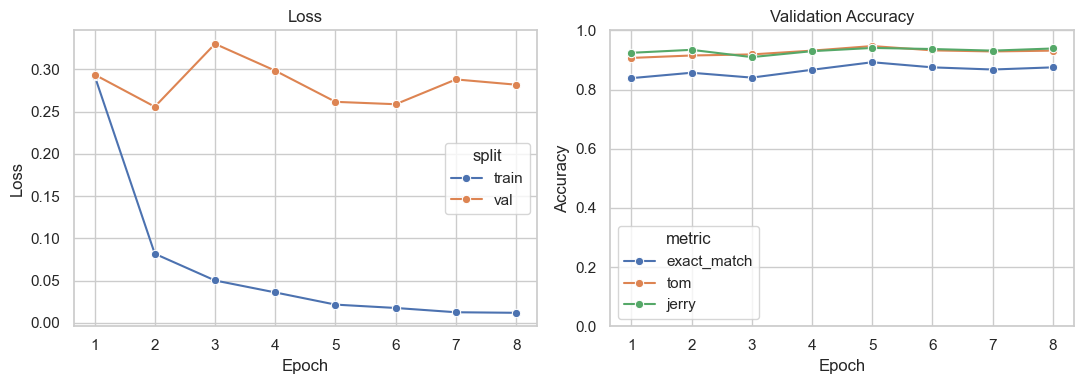

In [32]:
# history 리스트를 이용해 loss와 validation accuracy를 시각화합니다.
epochs = [h["epoch"] for h in history]
train_losses = [h["train_loss"] for h in history]
val_losses = [h["val_loss"] for h in history]
val_exact = [h["val_exact_match"] for h in history]
val_tom = [h["val_tom_acc"] for h in history]
val_jerry = [h["val_jerry_acc"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Loss 변화: train과 validation이 함께 내려가는지 확인합니다.
axes[0].plot(epochs, train_losses, marker="o", label="train")
axes[0].plot(epochs, val_losses, marker="o", label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 검증 정확도 변화: exact_match가 가장 엄격한 기준입니다.
axes[1].plot(epochs, val_exact, marker="o", label="exact_match")
axes[1].plot(epochs, val_tom, marker="o", label="tom")
axes[1].plot(epochs, val_jerry, marker="o", label="jerry")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Loss / Accuracy 그래프 해석

학습이 잘 되고 있다면 보통 `train_loss`와 `val_loss`가 함께 내려가고, `val_exact_match`, `val_tom_acc`, `val_jerry_acc`는 점점 올라갑니다. 이 경우 모델이 Tom/Jerry 특징을 긍정적으로 학습하고 있다고 볼 수 있습니다.

반대로 `train_loss`만 계속 내려가는데 `val_loss`가 올라가거나 검증 정확도가 떨어지면 과적합일 가능성이 큽니다. 이때는 `EPOCHS`를 줄이거나 augmentation을 늘리거나, learning rate를 조금 낮춰보는 것이 좋습니다.

가장 좋은 흐름은 `val_loss`가 꾸준히 감소하다가 완만하게 멈추고, 검증 정확도가 안정적으로 유지되는 형태입니다. 아래 정확도 계산 셀에서 저장된 best 모델 기준 성능을 숫자로 다시 확인할 수 있습니다.

In [33]:
# 저장된 best model 로드
checkpoint = torch.load(best_path, map_location=DEVICE)
model = build_model(use_pretrained=False).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("loaded", best_path, "epoch", checkpoint["epoch"], "val_loss", checkpoint["val_loss"])

loaded /Users/chxe_01/Downloads/archive/efficientnet_b0_tom_jerry_best.pt epoch 2 val_loss 0.25568316712527245


In [34]:
def evaluate_model(model, loader, threshold=0.5):
    """검증 데이터에서 정확도, precision, recall, f1을 계산합니다."""
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, targets in tqdm(loader, leave=False):
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)

            logits = model(images)
            loss = criterion(logits, targets)
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).float()

            total_loss += loss.item() * images.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())

    preds = torch.cat(all_preds)
    targets = torch.cat(all_targets)

    exact_match = (preds == targets).all(dim=1).float().mean().item()
    per_label_acc = (preds == targets).float().mean(dim=0)

    tp = ((preds == 1) & (targets == 1)).sum(dim=0).float()
    fp = ((preds == 1) & (targets == 0)).sum(dim=0).float()
    fn = ((preds == 0) & (targets == 1)).sum(dim=0).float()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        "loss": total_loss / len(loader.dataset),
        "exact_match_acc": exact_match,
        "tom_acc": per_label_acc[0].item(),
        "jerry_acc": per_label_acc[1].item(),
        "tom_precision": precision[0].item(),
        "jerry_precision": precision[1].item(),
        "tom_recall": recall[0].item(),
        "jerry_recall": recall[1].item(),
        "tom_f1": f1[0].item(),
        "jerry_f1": f1[1].item(),
    }

val_scores = evaluate_model(model, val_loader, threshold=0.5)

print("Best model validation scores")
for key, value in val_scores.items():
    print(f"{key}: {value:.4f}")

  0%|          | 0/35 [00:00<?, ?it/s]

Best model validation scores
loss: 0.2557
exact_match_acc: 0.8569
tom_acc: 0.9152
jerry_acc: 0.9344
tom_precision: 0.8938
jerry_precision: 0.9250
tom_recall: 0.9387
jerry_recall: 0.8981
tom_f1: 0.9157
jerry_f1: 0.9113


## 정확도 결과 해석

`exact_match_acc`는 Tom과 Jerry 두 라벨을 모두 맞힌 비율입니다. 이 값이 높을수록 모델이 한 프레임의 전체 상태를 잘 분류하고 있다는 뜻입니다.

`tom_acc`, `jerry_acc`는 각 캐릭터별 정확도입니다. 둘 중 하나만 낮다면 해당 캐릭터가 작게 나오거나 가려진 장면에서 더 어려워하고 있을 가능성이 있습니다.

`precision`은 모델이 있다고 예측했을 때 실제로 맞은 비율이고, `recall`은 실제로 있는 캐릭터를 얼마나 놓치지 않았는지입니다. `precision`은 높은데 `recall`이 낮으면 모델이 조심스럽게 예측해서 놓치는 경우가 많고, `recall`은 높은데 `precision`이 낮으면 너무 쉽게 있다고 판단하는 경향이 있습니다.

`f1`은 precision과 recall의 균형 점수입니다. 보통 `accuracy`와 함께 `f1`도 같이 높아지면 긍정적인 학습 결과로 볼 수 있습니다. 반대로 loss는 낮아졌는데 f1이나 exact match가 낮다면 threshold 조정이나 데이터 split, augmentation을 다시 확인해보는 것이 좋습니다.

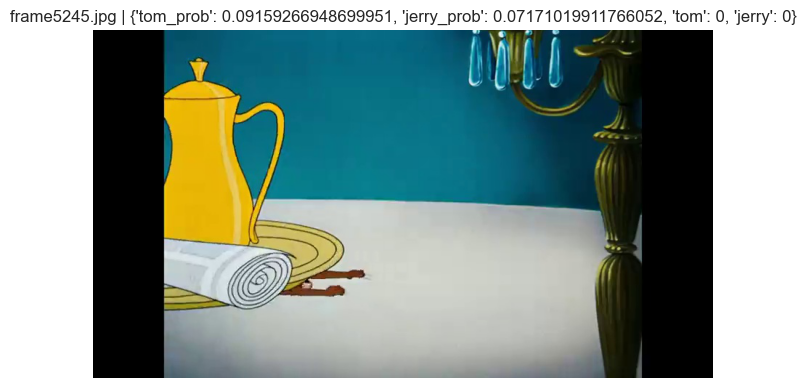

{'tom_prob': 0.09159266948699951,
 'jerry_prob': 0.07171019911766052,
 'tom': 0,
 'jerry': 0}

In [35]:
def predict_image(image_path, threshold=0.5):
    """이미지 하나를 넣으면 Tom/Jerry 확률과 0/1 예측을 반환합니다."""
    image_path = Path(image_path)
    raw = Image.open(image_path).convert("RGB")
    x = val_tfms(raw).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits)[0].detach().cpu().numpy()

    result = {
        "tom_prob": float(probs[0]),
        "jerry_prob": float(probs[1]),
        "tom": int(probs[0] >= threshold),
        "jerry": int(probs[1] >= threshold),
    }
    return raw, result

sample = random.choice(val_rows)
raw, result = predict_image(sample["path"])
plt.figure(figsize=(8, 5))
plt.imshow(raw)
plt.axis("off")
plt.title(f"{Path(sample['path']).name} | {result}")
plt.show()
result

In [36]:
# challenges.csv에 적힌 어려운 프레임들을 따로 예측해봅니다.
if CHALLENGE_CSV.exists():
    challenge_rows = []
    with open(CHALLENGE_CSV, newline="") as f:
        for row in csv.DictReader(f):
            path = DATA_DIR / row["folder"] / row["image_name"]
            _, pred = predict_image(path)
            challenge_rows.append({
                "folder": row["folder"],
                "image_name": row["image_name"],
                **pred,
            })

    for row in challenge_rows[:20]:
        print(row)
else:
    print("challenges.csv가 없습니다.")

{'folder': 'jerry', 'image_name': 'frame360.jpg', 'tom_prob': 0.011438659392297268, 'jerry_prob': 0.9997071623802185, 'tom': 0, 'jerry': 1}
{'folder': 'jerry', 'image_name': 'frame1794.jpg', 'tom_prob': 0.003044774988666177, 'jerry_prob': 0.9997382760047913, 'tom': 0, 'jerry': 1}
{'folder': 'jerry', 'image_name': 'frame1795.jpg', 'tom_prob': 0.003448755946010351, 'jerry_prob': 0.9996770620346069, 'tom': 0, 'jerry': 1}
{'folder': 'jerry', 'image_name': 'frame2231.jpg', 'tom_prob': 0.031051069498062134, 'jerry_prob': 0.9995577931404114, 'tom': 0, 'jerry': 1}
{'folder': 'jerry', 'image_name': 'frame2234.jpg', 'tom_prob': 0.015549725852906704, 'jerry_prob': 0.9847416281700134, 'tom': 0, 'jerry': 1}
{'folder': 'jerry', 'image_name': 'frame2941.jpg', 'tom_prob': 0.007544497959315777, 'jerry_prob': 0.9975125789642334, 'tom': 0, 'jerry': 1}
{'folder': 'jerry', 'image_name': 'frame2942.jpg', 'tom_prob': 0.008738623932003975, 'jerry_prob': 0.9983128309249878, 'tom': 0, 'jerry': 1}
{'folder': 'je

# 모델 분석

아래 셀들은 단순히 정확도만 보는 것이 아니라, 모델이 어떤 라벨 조합에서 강하고 약한지 분석하기 위한 코드입니다. 포트폴리오에서는 이런 분석을 함께 보여주면 “모델 학습”보다 한 단계 더 나아가 “모델 진단과 개선 방향 도출”까지 했다는 인상을 줄 수 있습니다.

In [37]:
def collect_predictions(model, loader):
    """검증 데이터 전체에 대한 확률, 예측값, 실제값을 모읍니다."""
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for images, targets in tqdm(loader, leave=False):
            images = images.to(DEVICE)
            logits = model(images)
            probs = torch.sigmoid(logits).cpu()

            all_probs.append(probs)
            all_targets.append(targets.cpu())

    probs = torch.cat(all_probs)
    targets = torch.cat(all_targets)
    return probs, targets

val_probs, val_targets = collect_predictions(model, val_loader)
val_preds = (val_probs >= 0.5).float()

print("val_probs shape:", tuple(val_probs.shape))
print("val_targets shape:", tuple(val_targets.shape))

  0%|          | 0/35 [00:00<?, ?it/s]

val_probs shape: (1097, 2)
val_targets shape: (1097, 2)


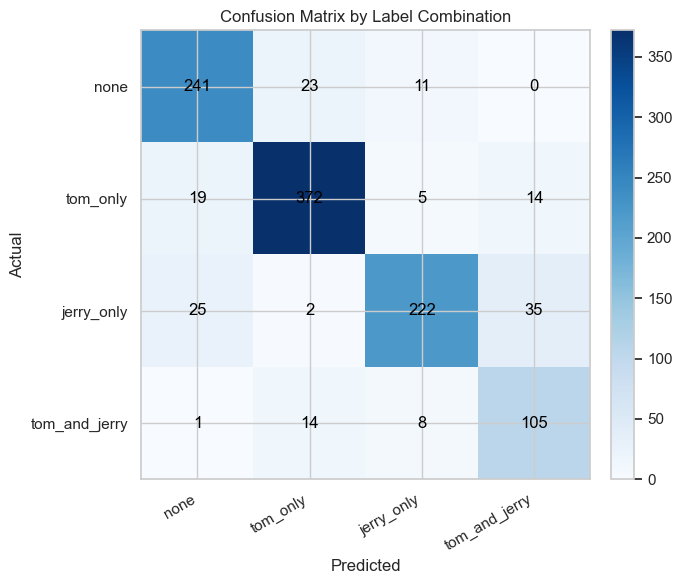

In [38]:
def label_pair_to_class(tom, jerry):
    """[tom, jerry] 멀티라벨을 4개 클래스 이름으로 바꿉니다."""
    tom = int(tom)
    jerry = int(jerry)
    if tom == 0 and jerry == 0:
        return "none"
    if tom == 1 and jerry == 0:
        return "tom_only"
    if tom == 0 and jerry == 1:
        return "jerry_only"
    return "tom_and_jerry"

class_names = ["none", "tom_only", "jerry_only", "tom_and_jerry"]
class_to_idx = {name: i for i, name in enumerate(class_names)}

true_classes = [label_pair_to_class(t[0], t[1]) for t in val_targets.numpy()]
pred_classes = [label_pair_to_class(p[0], p[1]) for p in val_preds.numpy()]

conf_mat = np.zeros((len(class_names), len(class_names)), dtype=int)
for true_name, pred_name in zip(true_classes, pred_classes):
    conf_mat[class_to_idx[true_name], class_to_idx[pred_name]] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(conf_mat, cmap="Blues")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix by Label Combination")

for i in range(conf_mat.shape[0]):
    for j in range(conf_mat.shape[1]):
        ax.text(j, i, conf_mat[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 조합별 Confusion Matrix 해석

이 표는 멀티라벨 결과를 `none`, `tom_only`, `jerry_only`, `tom_and_jerry` 네 가지 상태로 바꿔서 본 것입니다. 대각선 숫자가 클수록 좋은 모델입니다.

포트폴리오에서는 대각선 밖의 숫자를 중심으로 해석하면 좋습니다. 예를 들어 `tom_and_jerry`를 `tom_only`로 자주 예측한다면 Jerry가 작거나 가려진 상황에서 놓치는 문제가 있을 수 있습니다. 반대로 `none`을 캐릭터가 있다고 예측한다면 배경 물체나 다른 캐릭터를 Tom/Jerry로 혼동했을 가능성이 있습니다.

Best threshold by macro F1: {'threshold': 0.4500000000000001, 'exact_match': 0.8568823933601379, 'macro_f1': 0.9139198064804077, 'tom_f1': 0.9162916541099548, 'jerry_f1': 0.9115478992462158}
Best threshold by exact match: {'threshold': 0.6500000000000001, 'exact_match': 0.8596171140670776, 'macro_f1': 0.9130338430404663, 'tom_f1': 0.9181232452392578, 'jerry_f1': 0.9079444408416748}


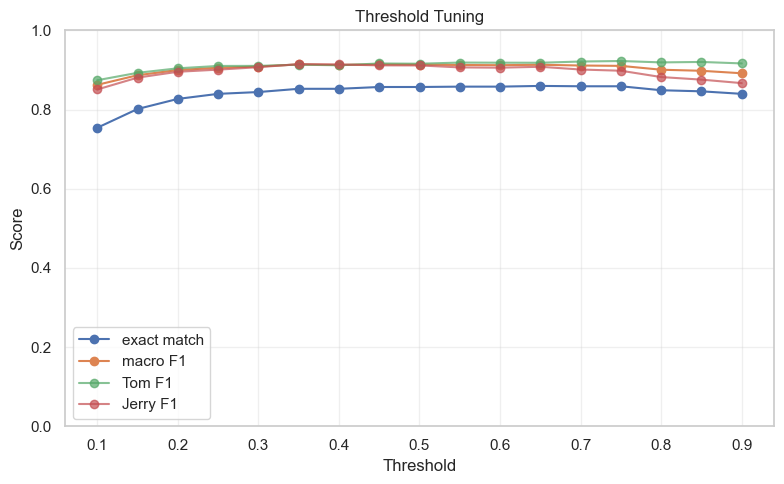

In [39]:
def score_at_threshold(probs, targets, threshold):
    """threshold별 exact match와 라벨별 F1을 계산합니다."""
    preds = (probs >= threshold).float()
    exact = (preds == targets).all(dim=1).float().mean().item()

    tp = ((preds == 1) & (targets == 1)).sum(dim=0).float()
    fp = ((preds == 1) & (targets == 0)).sum(dim=0).float()
    fn = ((preds == 0) & (targets == 1)).sum(dim=0).float()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    macro_f1 = f1.mean().item()

    return exact, macro_f1, f1[0].item(), f1[1].item()

threshold_rows = []
for threshold in np.arange(0.1, 0.91, 0.05):
    exact, macro_f1, tom_f1, jerry_f1 = score_at_threshold(val_probs, val_targets, float(threshold))
    threshold_rows.append({
        "threshold": float(threshold),
        "exact_match": exact,
        "macro_f1": macro_f1,
        "tom_f1": tom_f1,
        "jerry_f1": jerry_f1,
    })

best_by_f1 = max(threshold_rows, key=lambda r: r["macro_f1"])
best_by_exact = max(threshold_rows, key=lambda r: r["exact_match"])

print("Best threshold by macro F1:", best_by_f1)
print("Best threshold by exact match:", best_by_exact)

plt.figure(figsize=(8, 5))
plt.plot([r["threshold"] for r in threshold_rows], [r["exact_match"] for r in threshold_rows], marker="o", label="exact match")
plt.plot([r["threshold"] for r in threshold_rows], [r["macro_f1"] for r in threshold_rows], marker="o", label="macro F1")
plt.plot([r["threshold"] for r in threshold_rows], [r["tom_f1"] for r in threshold_rows], marker="o", label="Tom F1", alpha=0.7)
plt.plot([r["threshold"] for r in threshold_rows], [r["jerry_f1"] for r in threshold_rows], marker="o", label="Jerry F1", alpha=0.7)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Threshold Tuning 해석

기본 threshold는 `0.5`이지만, 실제 프로젝트에서는 이 기준값을 조정해 성능을 개선할 수 있습니다. 위 그래프에서 `macro F1`이 가장 높은 threshold는 Tom과 Jerry를 균형 있게 맞히는 기준으로 볼 수 있습니다.

포트폴리오에서는 “기본값 0.5만 사용하지 않고, 검증 데이터에서 threshold를 탐색했다”는 점이 좋은 포인트입니다. 특히 Jerry처럼 작게 등장하는 경우가 많다면 threshold를 낮췄을 때 recall이 좋아질 수 있습니다.

mistakes: 157 / 1097


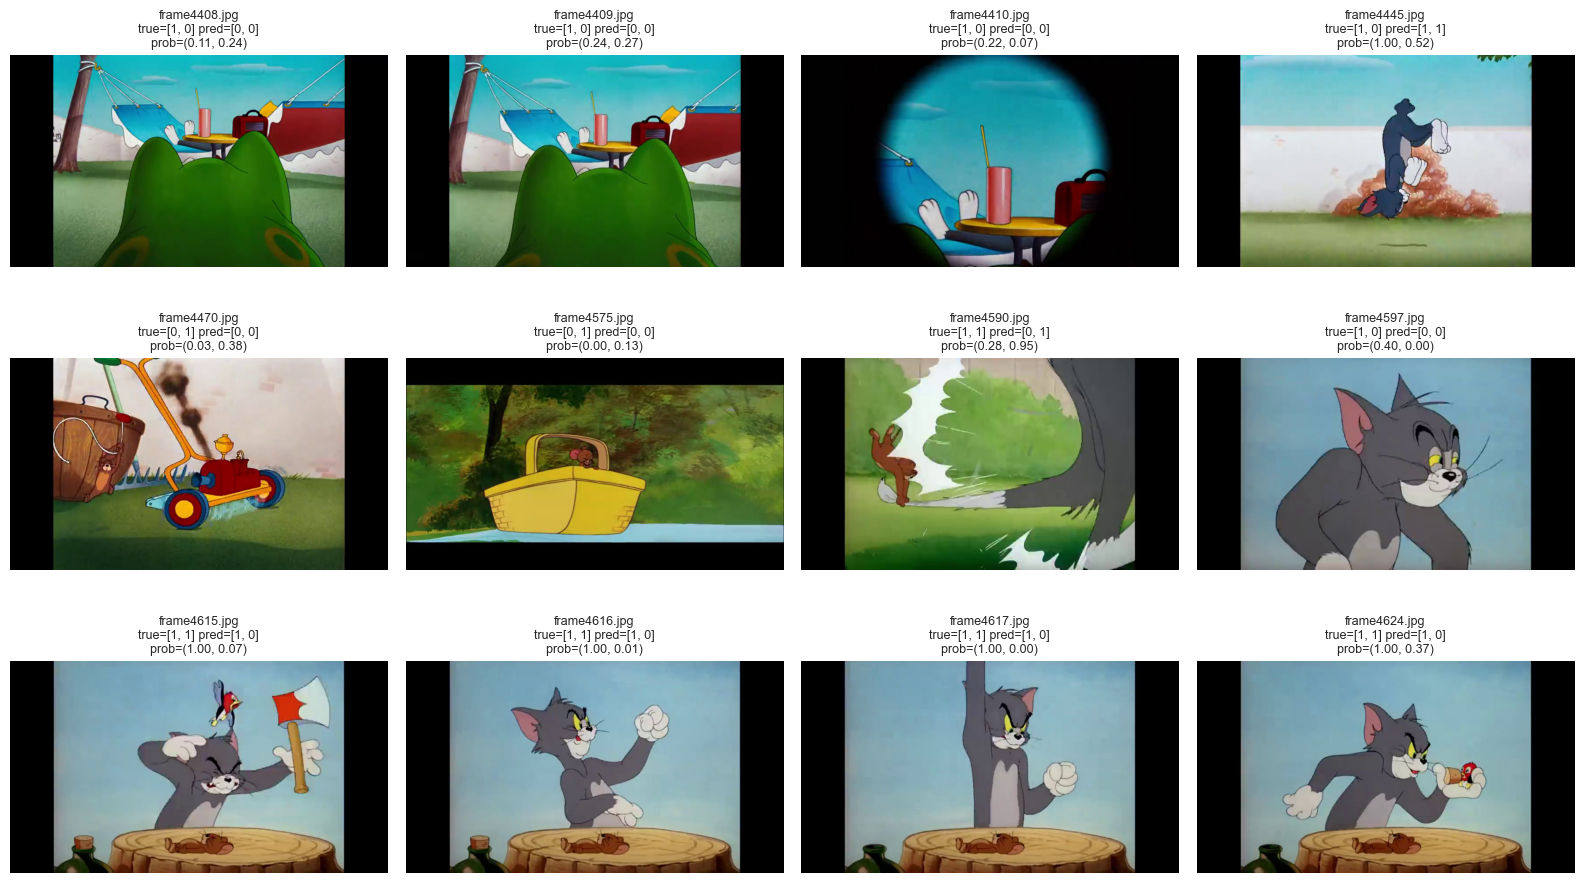

In [40]:
def show_mistakes(items, probs, targets, threshold=0.5, max_images=12):
    """틀린 검증 이미지를 모아 시각화합니다."""
    preds = (probs >= threshold).float()
    mistake_idxs = [i for i in range(len(items)) if not torch.equal(preds[i], targets[i])]

    print("mistakes:", len(mistake_idxs), "/", len(items))
    if not mistake_idxs:
        print("틀린 샘플이 없습니다.")
        return

    selected = mistake_idxs[:max_images]
    cols = 4
    rows_count = math.ceil(len(selected) / cols)
    plt.figure(figsize=(cols * 4, rows_count * 3.2))

    for plot_i, idx in enumerate(selected, 1):
        item = items[idx]
        image = Image.open(item["path"]).convert("RGB")
        true_label = [int(targets[idx][0]), int(targets[idx][1])]
        pred_label = [int(preds[idx][0]), int(preds[idx][1])]
        prob_label = [float(probs[idx][0]), float(probs[idx][1])]

        plt.subplot(rows_count, cols, plot_i)
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"{item['filename']}\ntrue={true_label} pred={pred_label}\nprob=({prob_label[0]:.2f}, {prob_label[1]:.2f})",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()

show_mistakes(val_rows, val_probs, val_targets, threshold=0.5, max_images=12)

## Error Analysis 해석

틀린 이미지를 직접 보면 숫자만으로는 알기 어려운 문제가 보입니다. 예를 들어 캐릭터가 화면 가장자리에 있거나, 일부만 보이거나, 다른 캐릭터와 색/형태가 비슷한 경우 모델이 헷갈릴 수 있습니다.

이 셀은 포트폴리오에서 가장 유용합니다. 단순히 “정확도 90%”라고 말하는 것보다, “오분류 샘플을 확인해보니 작은 객체와 부분 가림에서 약했다. 따라서 다음 개선 방향은 crop/augmentation/더 많은 hard case 수집이다”라고 말할 수 있기 때문입니다.

  0%|          | 0/1 [00:00<?, ?it/s]

Challenge set size: 32
exact_match, macro_f1, tom_f1, jerry_f1: (0.96875, 0.9864864945411682, 0.9729729890823364, 1.0)
mistakes: 1 / 32


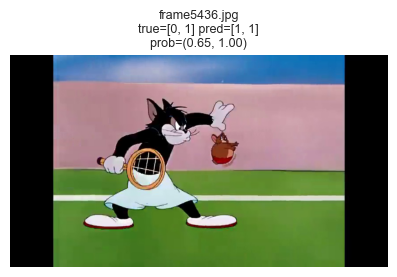

In [41]:
# challenges.csv에 있는 어려운 샘플만 따로 성능을 확인합니다.
if CHALLENGE_CSV.exists():
    challenge_items = []
    with open(CHALLENGE_CSV, newline="") as f:
        for row in csv.DictReader(f):
            folder = row["folder"]
            filename = row["image_name"]
            path = DATA_DIR / folder / filename

            if folder == "tom":
                tom, jerry = 1, 0
            elif folder == "jerry":
                tom, jerry = 0, 1
            elif folder == "tom_jerry_1":
                tom, jerry = 1, 1
            else:
                tom, jerry = 0, 0

            challenge_items.append({
                "filename": filename,
                "folder": folder,
                "path": path,
                "tom": tom,
                "jerry": jerry,
            })

    challenge_ds = TomJerryDataset(challenge_items, val_tfms)
    challenge_loader = DataLoader(challenge_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    challenge_probs, challenge_targets = collect_predictions(model, challenge_loader)
    challenge_scores = score_at_threshold(challenge_probs, challenge_targets, threshold=0.5)

    print("Challenge set size:", len(challenge_items))
    print("exact_match, macro_f1, tom_f1, jerry_f1:", challenge_scores)
    show_mistakes(challenge_items, challenge_probs, challenge_targets, threshold=0.5, max_images=12)
else:
    print("challenges.csv가 없습니다.")

## Challenge Set 해석

`challenges.csv`는 일반 검증 데이터보다 어려운 케이스를 모아둔 것으로 볼 수 있습니다. 전체 검증 성능은 높지만 challenge set 성능이 낮다면, 모델이 쉬운 연속 프레임에는 강하지만 어려운 장면에는 아직 약하다는 뜻입니다.

이 차이는 포트폴리오에서 좋은 인사이트가 됩니다. “일반 검증 성능과 hard case 성능을 따로 평가했다”는 점은 실제 업무에서 모델을 더 현실적으로 검증하는 방식입니다.